In [14]:
from photonpairlab.crystal.material import MaterialFactory

mat = MaterialFactory.create("ktp1")
n_y = mat.refractive_index(1.55, "y", temperature=30)
ng_y = mat.group_index(1.55, axis="y", temperature=30)
print(n_y, ng_y)


1.7341272454061591 1.7640821783846856


In [15]:
# Initialize crystal parameters
coherence_length1 = 46.21e-6                
coherence_length2 = 46.18e-6
crystal_length = 30e-3            
temperature1 = 30                 
temperature2 = 30
domain_width = 18e-6  

In [16]:
from photonpairlab.crystal import Crystal
from photonpairlab.laser import CWLaser, PulsedLaser
from photonpairlab.spdc.simulation import SPDC_Simulation
from photonpairlab.spdc import SpectralAnalyzer
from photonpairlab.spdc import HOMAnalyzer
from photonpairlab.spdc import SPDC_Plotter
from photonpairlab.spdc.utils import *
import matplotlib.pyplot as plt
import numpy as np

In [17]:
crystal1 = Crystal(crystal_length=crystal_length, material=mat,
                  coherence_length=coherence_length1, w=domain_width, 
                  T=temperature1, pm_strategy="quasi", spdc_type="type-II")

In [18]:
wavelength_pump1 = 775e-9

pulse_duration = 1.7e-12            # Pulse duration (in seconds)
laser1 = PulsedLaser(wavelength_pump1, pulse_duration=pulse_duration)
wavelength_signal1 = wavelength_pump1 * 2
wavelength_idler1 = wavelength_pump1 * 2

crystal1.generate_poling(laser=laser1, mode="periodic", wavelength_signal=wavelength_signal1, wavelength_idler=wavelength_idler1, resolution=5)
dev = 5
start_wavelength = 1545e-9
end_wavelength = 1560e-9

# Create and run the simulation
simulation1 = SPDC_Simulation(crystal1, 
                              laser1,
                              wavelength_signal_range = [start_wavelength, end_wavelength], 
                              wavelength_idler_range = [start_wavelength, end_wavelength])
results1 = simulation1.run_simulation(steps=100)

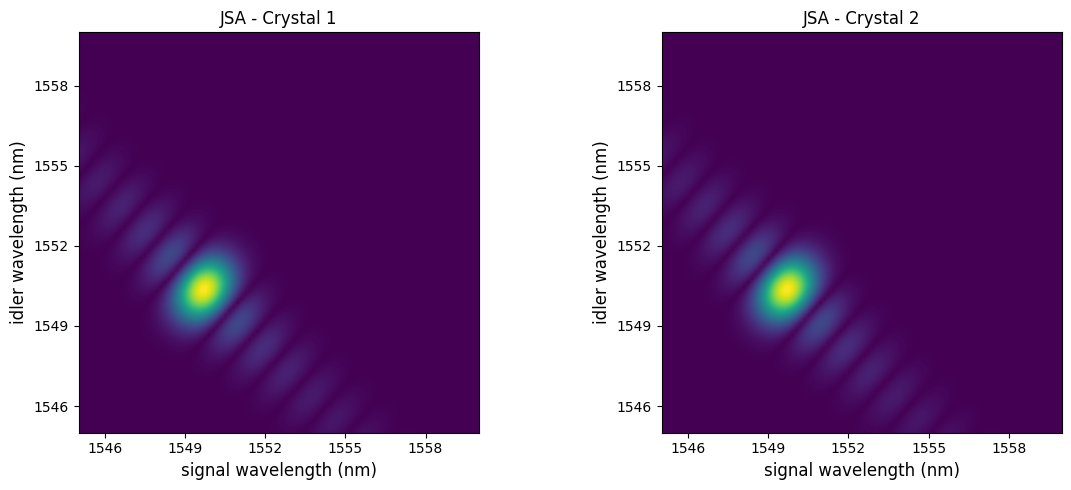

In [19]:
# Plot the results
plotter1 = SPDC_Plotter(results1)
plotter2 = SPDC_Plotter(results1)


# Plot the results side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
_, ax1 = plotter1.plot_result(key='JSA', fig=fig, ax=ax1)
_, ax2 = plotter2.plot_result(key='JSA', fig=fig, ax=ax2)
ax1.set_title("JSA - Crystal 1")
ax2.set_title("JSA - Crystal 2")

plt.tight_layout()
plt.show()